#### The formation efficencies of the binary white dwarf (WDWD) and binary neutron star (NSNS) systems that merge within a Hubble Time

### Imports and definitions

In [1]:
import h5py as h5 
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import tol_colors as tc

import useful_fncs
import utils_from_others
import figure_utils

# plotting imports
# import for axes labels 
plt.rc('text.latex', preamble=r'\usepackage{textgreek}')
plt.rc('font', family='serif')
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif"
})

### Read in Data

In order to get accurate formation efficiencies for both the WDWD and NSNS systems, we will use the WDWD optimized run of COMPAS to calculate the WDWD formation efficiences and the NSNS optimized run to calculate the BNS formation efficiences.

This means we must first read in each simulation output at a time.

We'll mask the data for our systems of interest in each case using the DCOmask filter. For the WDWD, we will select any WDWD systems with at least one carbon oxygen white dwarf (COWD) that merge within a Hubble Time. For the NSNS case, we will select any system with two neutron stars that merge within a Hubble Time

In [2]:
# let's read in our files for the fiducial case

## NSNS optimized run

# let's first look at the NSNS_output
pathToH5_NSNS = '/expanse/lustre/scratch/msantiago/temp_project/COMPAS_DATA/N5e6_NSNS_CE_alpha025/MainRun/COMPAS_Output_wWeights.h5'

Data_NSNS  = h5.File(pathToH5_NSNS, "r")

DCOs_NSNS = Data_NSNS['BSE_Double_Compact_Objects'] # getting the DCO objects

DATA_SPS = Data_NSNS['BSE_System_Parameters']

# gathering the double compact objects that we have computed rates for
DCO_mask_NSNS = Data_NSNS['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['DCOmask'][()]

In [3]:
# gathering information to mask the data even more
# merges in a Hubble Time
Merges_Hubble_Time = Data_NSNS['BSE_Double_Compact_Objects']['Merges_Hubble_Time'][()]
condition_mergers = Merges_Hubble_Time == True

# gathering just the DCO objects that merge within a Hubble Time
stellar_types_all_1 = DCOs_NSNS['Stellar_Type(1)'][()]
stellar_types_1_merged = stellar_types_all_1[DCO_mask_NSNS*condition_mergers]
# stellar_types_1_merged = stellar_types_1[condition_mergers]

stellar_types_all_2 = DCOs_NSNS['Stellar_Type(2)'][()]
stellar_types_2_merged = stellar_types_all_2[DCO_mask_NSNS*condition_mergers]

# bool for just the NSNS systems
NSNS_systems_bool = np.logical_and(stellar_types_1_merged==13, stellar_types_2_merged==13)

# gathering the mixture weight info
mixture_weights_all = DCOs_NSNS['mixture_weight'][()]
mixtrue_weights_merged = mixture_weights_all[DCO_mask_NSNS*condition_mergers]
mixture_weights_merged_NSNS = mixtrue_weights_merged[NSNS_systems_bool]

# gathering the metallicity info
Metallicity_DCO = Data_NSNS['BSE_Double_Compact_Objects']['Metallicity@ZAMS(1)'][()]
metallicity_merged = Metallicity_DCO[DCO_mask_NSNS*condition_mergers]
metallicity_merged_NSNS = metallicity_merged[NSNS_systems_bool]

#### Let's do the same for the BWD systems

In [4]:
## WDWD optimized run
pathToH5_WDWD = '/expanse/lustre/scratch/msantiago/temp_project/COMPAS_DATA/N5e6_MassiveWDWD_NSNS_CE_alpha025/MainRun/COMPAS_Output_wWeights.h5'

Data_WDWD  = h5.File(pathToH5_WDWD, "r")

DCOs_WDWD = Data_WDWD['BSE_Double_Compact_Objects'] # getting the DCO objects

# gathering the double compact objects that we have computed rates for
DCO_mask_WDWD = Data_WDWD['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['DCOmask'][()]

DATA_SPS_WDWD = Data_WDWD['BSE_System_Parameters']

In [5]:
# merging conditions
Merges_Hubble_Time_WDopt = Data_WDWD['BSE_Double_Compact_Objects']['Merges_Hubble_Time'][()]
condition_mergers_WDopt = Merges_Hubble_Time_WDopt == True

stellar_types_all_1_WD_opt = DCOs_WDWD['Stellar_Type(1)'][()]
stellar_types_1_merged_WDopt = stellar_types_all_1_WD_opt[DCO_mask_WDWD*condition_mergers_WDopt]

stellar_types_all_2_WDopt = DCOs_WDWD['Stellar_Type(2)'][()]
stellar_types_2_merged_WDopt = stellar_types_all_2_WDopt[DCO_mask_WDWD*condition_mergers_WDopt]

# BWD bool with at least one COWD
HeWD_bool_WDWD,COWD_bool_WDWD,ONeWD_bool_WDWD,HeCOWD_bool_WDWD,HeONeWD_bool_WDWD,COHeWD_bool_WDWD,COONeWD_bool_WDWD,ONeHeWD_bool_WDWD,ONeCOWD_bool_WDWD = useful_fncs.WD_BINARY_BOOLS(stellar_types_1_merged_WDopt, stellar_types_2_merged_WDopt)
carbon_oxygen_bool_WDWD_merged_WDopt = np.logical_or(ONeCOWD_bool_WDWD,np.logical_or(COONeWD_bool_WDWD,np.logical_or(COHeWD_bool_WDWD,np.logical_or(COWD_bool_WDWD,HeCOWD_bool_WDWD))))

mixture_weights_all_WDopt = DCOs_WDWD['mixture_weight'][()]
mixtrue_weights_merged_WDopt = mixture_weights_all_WDopt[DCO_mask_WDWD*condition_mergers_WDopt]
mixture_weights_merged_COWD_WDopt = mixtrue_weights_merged_WDopt[carbon_oxygen_bool_WDWD_merged_WDopt]

Metallicity_DCO_WDopt = DCOs_WDWD['Metallicity@ZAMS(1)'][()]
metallicity_merged_WDopt = Metallicity_DCO_WDopt[DCO_mask_WDWD*condition_mergers_WDopt]
metallicity_merged_COWD_WDopt = metallicity_merged_WDopt[carbon_oxygen_bool_WDWD_merged_WDopt]

### Calculating the average star forming mass per binary

In order to compute the formation efficiences we need to find the average star forming mass used to form each of our systems of interest. We then need to consider how representative each of these systems are of the true universe by weighing them by their mixture weights.

Using the formation efficiencies tutorial created by Floor Broekgaarden as well: https://github.com/FloorBroekgaarden/GROWL-catalog-public/blob/main/CosmicIntegration/formation_efficiency_COMPAS.ipynb

In [6]:
# let's find the minimum mass
mass_1 = DATA_SPS['Mass@ZAMS(1)'][()]
mass_2 = DATA_SPS['Mass@ZAMS(2)'][()]
m1min_NSNS = min(mass_1)
m1max_NSNS = max(mass_1)
m2min_NSNS = min(mass_2)
print(m1min_NSNS, m1max_NSNS, m2min_NSNS)

5.000000088386589 149.99930429323493 0.10000213157468987


In [7]:
# let's use the information above to fins the average star forming mass per binary

m_rep_per_binary = utils_from_others.analytical_star_forming_mass_per_binary_using_kroupa_imf(5, 150, 0.1, 0.7)

Integrating from 0.01 to 0.08 for fbin = 0.7 and exponent = -0.3
Integrating from 0.08 to 0.5 for fbin = 0.7 and exponent = -1.3
Integrating from 0.5 to 1 for fbin = 0.7 and exponent = -2.3
Integrating from 1 to 10 for fbin = 0.7 and exponent = -2.3
Integrating from 10 to 200 for fbin = 0.7 and exponent = -2.3


In [8]:
print('1 binary in COMPAS NSNS optimized run represents', m_rep_per_binary, ' solar masses formed')

# now calculate the number of binaries in COMPAS simulation (over the entire simulation)
n_binaries = np.shape(Data_NSNS['BSE_System_Parameters']['SEED'][()])[0]
print(n_binaries)


total_mass_evolved_compas = n_binaries * m_rep_per_binary
print(total_mass_evolved_compas, ' [Msun]')

formation_efficiencies_NSNS = mixture_weights_merged_NSNS/total_mass_evolved_compas

1 binary in COMPAS NSNS optimized run represents 101.71305071633428  solar masses formed
5000000
508565253.5816714  [Msun]


Let's do the same for the BWD optimized run

In [9]:
# let's find the minimum mass
mass_1_WDWD = DATA_SPS_WDWD['Mass@ZAMS(1)'][()]
mass_2_WDWD = DATA_SPS_WDWD['Mass@ZAMS(2)'][()]
m1min_WDWD = min(mass_1_WDWD)
m1max_WDWD = max(mass_1_WDWD)
m2min_WDWD = min(mass_2_WDWD)
print(m1min_WDWD, m1max_WDWD, m2min_WDWD)

1.0000026200930308 149.95422800529892 0.1000012642956526


In [10]:
# let's use the information above to fins the average star forming mass per binary
m_rep_per_binary_WDWD = utils_from_others.analytical_star_forming_mass_per_binary_using_kroupa_imf(1, 150, 0.1, 0.7)

Integrating from 0.01 to 0.08 for fbin = 0.7 and exponent = -0.3
Integrating from 0.08 to 0.5 for fbin = 0.7 and exponent = -1.3
Integrating from 0.5 to 1 for fbin = 0.7 and exponent = -2.3
Integrating from 1 to 10 for fbin = 0.7 and exponent = -2.3
Integrating from 10 to 200 for fbin = 0.7 and exponent = -2.3


In [11]:
print('1 binary in COMPAS WDWD opimized run represents', m_rep_per_binary_WDWD, ' solar masses formed')

# now calculate the number of binaries in COMPAS simulation (over the entire simulation)
n_binaries_WDWD = np.shape(Data_WDWD['BSE_System_Parameters']['SEED'][()])[0]
print(n_binaries_WDWD)


total_mass_evolved_compas_WDWD = n_binaries_WDWD * m_rep_per_binary_WDWD
print(total_mass_evolved_compas_WDWD, ' [Msun]')

formation_efficiencies_COWD_WDopt = mixture_weights_merged_COWD_WDopt/total_mass_evolved_compas_WDWD

1 binary in COMPAS WDWD opimized run represents 13.014304811861441  solar masses formed
5000000
65071524.0593072  [Msun]


### Let's plot!

Text(0.5, 0.98, 'Formation Efficiencies')

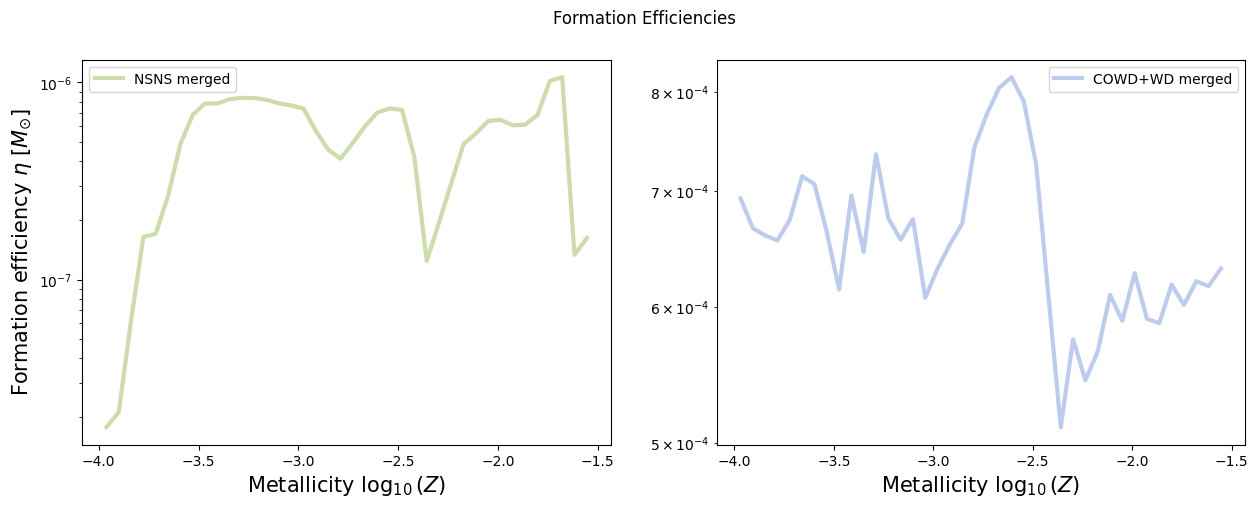

In [13]:
fig, axs = plt.subplots(1,2, figsize=(15, 5))

cset = tc.pale

### NSNS optimized
# NSNS
hist, bin_edges = np.histogram(np.log10(metallicity_merged_NSNS), weights=formation_efficiencies_NSNS, bins=40, density=True)
### can also change this to formation efficency/dlogZ

bin_centers = (bin_edges[0:-1] + bin_edges[1:])/2
normalization = np.sum(formation_efficiencies_NSNS)

# plotting
axs[0].plot(bin_centers, hist*normalization, color = cset.pale_green, lw=3, label='NSNS merged')


### WDWD optimized
# COWD + WD
hist_COWD_WDopt, bin_edges_COWD_WDopt = np.histogram(np.log10(metallicity_merged_COWD_WDopt), weights=formation_efficiencies_COWD_WDopt, bins=40, density=True)

bin_centers_COWD_WDopt = (bin_edges_COWD_WDopt[0:-1] + bin_edges_COWD_WDopt[1:])/2
normalization_COWD_WDopt = np.sum(formation_efficiencies_COWD_WDopt)

# plotting
axs[1].plot(bin_centers_COWD_WDopt, hist_COWD_WDopt*normalization_COWD_WDopt,color=cset.pale_blue, lw=3, label='COWD+WD merged')


axs[0].set_yscale('log')
axs[1].set_yscale('log')
# plt.ylim(10**-6, 10**-3.5)

axs[0].set_ylabel(r'Formation efficiency $\eta \ [M_{\odot}]$', fontsize=15)
axs[0].set_xlabel(r'Metallicity $\log_{10}(Z)$', fontsize=15)
axs[1].set_xlabel(r'Metallicity $\log_{10}(Z)$', fontsize=15)

axs[0].legend()
axs[1].legend()

fig.suptitle('Formation Efficiencies')

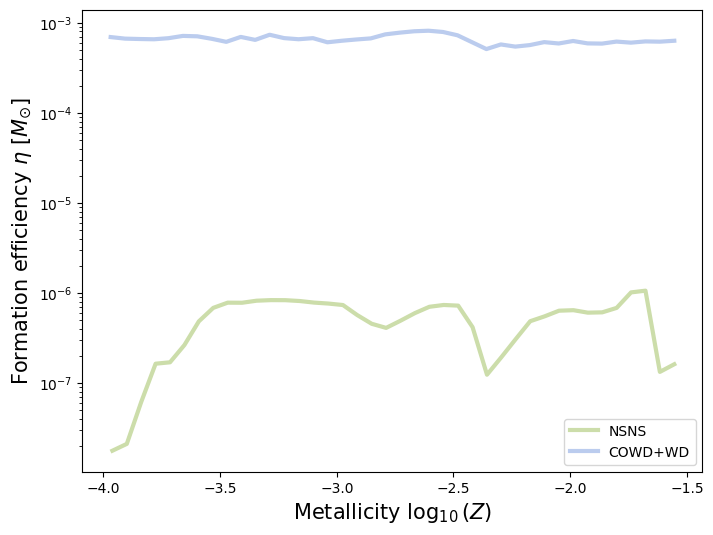

In [47]:
# plotting formation efficencies

fig, axs = plt.subplots(1,1, figsize=(8, 6))
cset = tc.pale

# NSNS
hist, bin_edges = np.histogram(np.log10(metallicity_merged_NSNS), weights=formation_efficiencies_NSNS, bins=40, density=True)

bin_centers = (bin_edges[0:-1] + bin_edges[1:])/2
normalization = np.sum(formation_efficiencies_NSNS)

# COWD + WD
hist_COWD, bin_edges_COWD = np.histogram(np.log10(metallicity_merged_COWD_WDopt), weights=formation_efficiencies_COWD_WDopt, bins=40, density=True)

bin_centers_COWD = (bin_edges_COWD[0:-1] + bin_edges_COWD[1:])/2
normalization_COWD = np.sum(formation_efficiencies_COWD_WDopt)

# plotting
axs.plot(bin_centers, hist*normalization, color = cset.pale_green, lw=3, label='NSNS')
axs.plot(bin_centers_COWD, hist_COWD*normalization_COWD, color=cset.pale_blue, lw=3, label='COWD+WD')


plt.yscale('log')
# plt.ylim(10**-6, 10**-3.5)

plt.ylabel(r'Formation efficiency $\eta \ [M_{\odot}]$', fontsize=15)
plt.xlabel(r'Metallicity $\log_{10}(Z)$', fontsize=15)
plt.legend()

### Close the hdf5 files

In [14]:
Data_NSNS.close()
Data_WDWD.close()